In [1]:
# =============================================================================
# CELDA 1: Importaciones y Funciones (Incluye lógicas para Gaussianas)
# =============================================================================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import warnings


warnings.simplefilter('ignore')

# Configuración visual global
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.size': 14, 'axes.labelsize': 16, 'axes.titlesize': 16, 
    'legend.fontsize': 12, 'figure.figsize': (10, 6),
    'lines.linewidth': 2, 'lines.markersize': 8, 'errorbar.capsize': 3
})

COLORS = {'Proton': 'royalblue', 'Helio': 'forestgreen', 'Oxigeno': 'purple', 'Hierro': 'firebrick', 'Mix': 'dimgray'}
MARKERS = {'SIBYLL': 'o', 'QGSJet': 's', 'EPOS': '^'}

def ensure_degrees(series, name="Var"):
    if series.abs().max() < 7.0: return np.rad2deg(series)
    return series

def ang_diff(a_deg, b_deg):
    return (a_deg - b_deg + 180) % 360 - 180

def fit_func_deg(phi_deg, A1):
    return 1.0 * (1 + A1 * np.cos(np.deg2rad(phi_deg)))

def calc_mf(val1, err1, val2, err2):
    denom = np.sqrt(err1**2 + err2**2)
    return np.abs(val1 - val2) / denom if denom > 0 else 0.0

def plot_annotated_gaussians(ax, mus, sigs, labels, colors, title):
    """Genera las gaussianas de distribución para el plot de Discriminación."""
    x_min = min([m - 4*s for m, s in zip(mus, sigs)])
    x_max = max([m + 4*s for m, s in zip(mus, sigs)])
    x = np.linspace(x_min, x_max, 500)
    max_y = 0
    
    for mu, sig, lab, col in zip(mus, sigs, labels, colors):
        y = norm.pdf(x, mu, sig)
        ax.plot(x, y, color=col, lw=2)
        ax.fill_between(x, y, alpha=0.15, color=col)
        peak = norm.pdf(mu, mu, sig)
        ax.text(mu, peak * 1.05, lab, ha='center', color=col, fontweight='bold', fontsize=11)
        if peak > max_y: max_y = peak

    ax.set_ylim(0, max_y * 1.2)
    ax.set_title(title, pad=15)
    ax.set_xlabel(r"Amplitud de Asimetría $A_1$")
    ax.set_ylabel("Densidad de Probabilidad")
    ax.grid(True, alpha=0.3)

In [2]:
# =============================================================================
# CELDA 2: Funciones Auxiliares (Ajustes, MF y Parseo)
# =============================================================================

def parse_metadata(folder_name):
    """Extrae metadatos basados en el nombre de la carpeta (ej. parquet_sib_proton_17)."""
    f = folder_name.lower()
    model = 'SIBYLL' if 'sib' in f else 'QGSJet' if 'qgs' in f else 'EPOS' if 'epos' in f else 'Unknown'
    
    if 'proton' in f: primary = 'Proton'
    elif 'hierro' in f or 'iron' in f: primary = 'Hierro'
    elif 'helio' in f or 'helium' in f: primary = 'Helio'
    elif 'oxigeno' in f or 'oxygen' in f: primary = 'Oxigeno'
    else: primary = 'Unknown'
        
    energy = '18.0-18.5' if '_18' in f else '17.5-18.0'
    return model, primary, energy

def fit_func(phi_rad, A1):
    """Función de asimetría del primer armónico."""
    return 1.0 * (1 + A1 * np.cos(phi_rad))

def calc_mf(val1, err1, val2, err2):
    """Calcula el Factor de Mérito (Merit Factor) entre dos distribuciones."""
    denom = np.sqrt(err1**2 + err2**2)
    if denom == 0: return 0.0
    return np.abs(val1 - val2) / denom

def ang_diff(a_deg, b_deg):
    return (a_deg - b_deg + 180) % 360 - 180

In [3]:
# =============================================================================
# CELDA 3: Carga Masiva de Datos
# =============================================================================
ROOT_DIR = "/home/lsilva/Github/ADST_Alexey_module_v9" 

all_dfs = []
for folder in os.listdir(ROOT_DIR):
    folder_path = os.path.join(ROOT_DIR, folder)
    if not os.path.isdir(folder_path): continue
        
    model, primary, energy = parse_metadata(folder)
    parquets = glob.glob(os.path.join(folder_path, "*.parquet"))
    
    for f in parquets:
        try:
            # Cargar columnas relevantes para no reventar la RAM
            df = pd.read_parquet(f, columns=[
                'event_id', 'counterId', 'theta_REC', 'theta_MC', 'phi_REC', 'phi_MC', 'logE_REC', 'logE_MC',
                'nMuones_REC', 'nMuones_MC', 'sdSignal_REC', 'sd_nMuons_MC', 'sd_nEM_MC', 'r_core',
                'phi_plane_sp', 'phi_plane_euler', 'phi_plane_ground', 'module_status'
            ])
            df = df.dropna(subset=['theta_REC', 'phi_REC', 'logE_REC'])
            df['Model'], df['Primary'], df['Energy'] = model, primary, energy
            all_dfs.append(df)
        except: pass

df_master = pd.concat(all_dfs, ignore_index=True)

# Dataset Guía para toda la primera parte: SIBYLL Proton 17.5
df_guia = df_master[(df_master['Model'] == 'SIBYLL') & (df_master['Primary'] == 'Proton') & (df_master['Energy'] == '17.5-18.0')].copy()
print(f"Data cargada. Mega-DF: {len(df_master):,} | Dataset Guía (SIB P 17.5): {len(df_guia):,}")

Data cargada. Mega-DF: 9,948,348 | Dataset Guía (SIB P 17.5): 1,532,829


In [4]:
print(df_master['Primary'].unique())

<ArrowStringArray>
['Helio', 'Oxigeno', 'Hierro', 'Proton']
Length: 4, dtype: str


In [5]:
# =========================================================================
# CELDA 4: CÁLCULO MASIVO DE ASIMETRÍA (Generación de df_res)
# =========================================================================
print("Generando bines y preparando datos del UMD...")

# 1. Definir Bines de Theta (en sen^2) para el Anillo Denso
s2_bins = np.linspace(np.sin(np.deg2rad(0))**2, np.sin(np.deg2rad(65))**2, 11)
theta_edges = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))

# 2. Filtrar Anillo Denso (90k)
df_umd = df_master[(df_master['counterId'] >= 90000) & (df_master['counterId'] < 100000)].copy()
df_umd['ThetaBin'] = pd.cut(df_umd['theta_REC'], bins=theta_edges, labels=False)

# 3. Preparar Phi Centrado
# OJO: Dependiendo si phi_plane_sp ya está en radianes, lo pasamos a grados
df_umd['phi_deg_centered'] = (np.rad2deg(df_umd['phi_plane_sp']) + 180) % 360 - 180
phi_bin_edges = np.linspace(-180, 180, 13)
phi_centers = (phi_bin_edges[:-1] + phi_bin_edges[1:]) / 2
df_umd['phi_bin'] = pd.cut(df_umd['phi_deg_centered'], bins=phi_bin_edges)

results = []

# Función local para extraer el ajuste A1
def get_a1(sub_df):
    prof = sub_df.groupby('phi_bin', observed=True)['nMuones_REC'].agg(['mean', 'sem']).dropna()
    if len(prof) < 8: return np.nan, np.nan
    norm = prof['mean'].mean()
    if norm == 0: return np.nan, np.nan
    
    try:
        popt, pcov = curve_fit(fit_func_deg, phi_centers, prof['mean']/norm, p0=[0.05], sigma=prof['sem']/norm, absolute_sigma=True)
        return popt[0], np.sqrt(pcov[0,0])
    except:
        return np.nan, np.nan

print("Calculando amplitudes de asimetría (A1) para cada primario...")
# Calcular para cada Modelo, Primario, Energía y Bin Theta
for (mod, prim, en, th_idx), sub_df in df_umd.groupby(['Model', 'Primary', 'Energy', 'ThetaBin']):
    a1, err = get_a1(sub_df)
    results.append({'Model': mod, 'Primary': prim, 'Energy': en, 'ThetaBin': th_idx, 'A1': a1, 'Err': err})

print("Calculando el dataset 'Mix' (promedio ciego de primarios)...")
# El MIX: Agrupa ignorando 'Primary' para promediar todos los eventos de esa energía y modelo
for (mod, en, th_idx), sub_df in df_umd.groupby(['Model', 'Energy', 'ThetaBin']):
    a1, err = get_a1(sub_df)
    results.append({'Model': mod, 'Primary': 'Mix', 'Energy': en, 'ThetaBin': th_idx, 'A1': a1, 'Err': err})

# Guardar en el DataFrame maestro de resultados
df_res = pd.DataFrame(results).dropna()
print(f"¡Listo! DataFrame 'df_res' generado exitosamente con {len(df_res)} puntos de ajuste.")

Generando bines y preparando datos del UMD...
Calculando amplitudes de asimetría (A1) para cada primario...
Calculando el dataset 'Mix' (promedio ciego de primarios)...
¡Listo! DataFrame 'df_res' generado exitosamente con 90 puntos de ajuste.


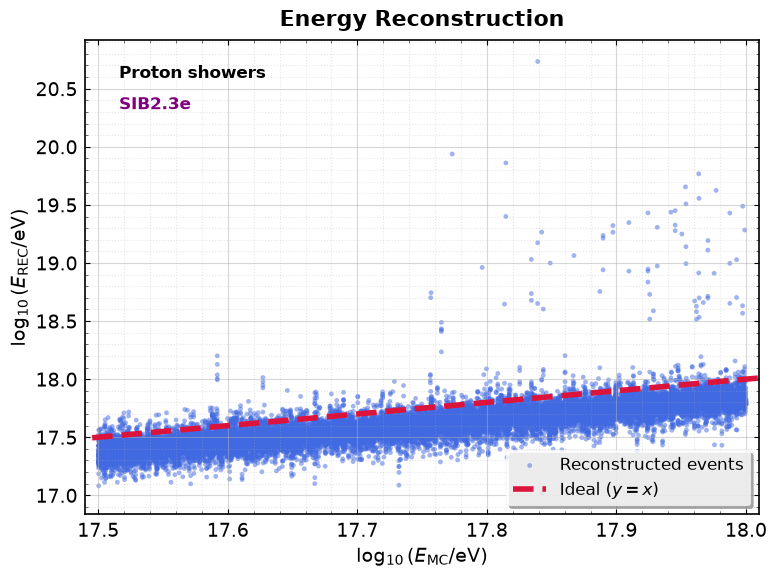

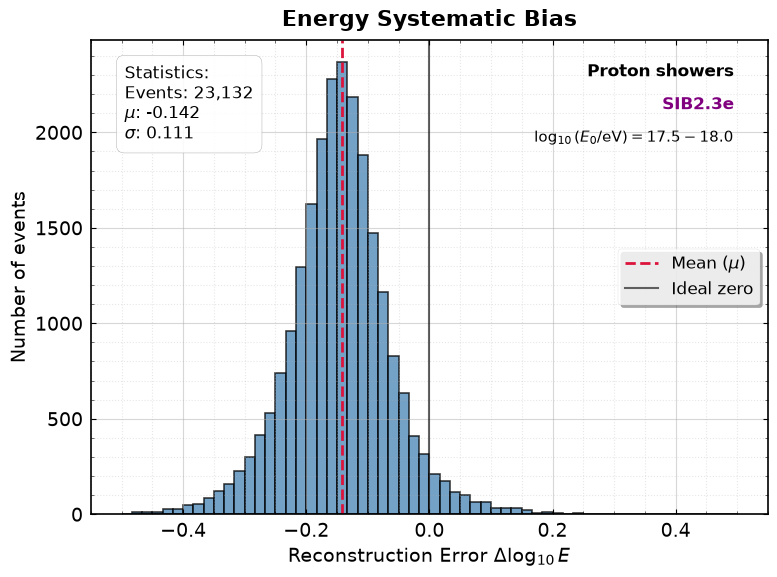

In [6]:
# =========================================================================
# CELDA 3: VALIDACIÓN DEL DATASET (ENERGÍA) - HÍBRIDO HEP + GRILLAS (INGLÉS)
# =========================================================================

# 1. Configuración de estilo (Tipografía HEP pero con leyenda y grillas habilitadas)
hep_style = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'xtick.direction': 'in', 
    'ytick.direction': 'in',
    'xtick.top': True, 
    'ytick.right': True,
    'xtick.minor.visible': True, 
    'ytick.minor.visible': True,
    'axes.linewidth': 1.2,
    'legend.frameon': True,
    'legend.shadow': True,
    # --- LÍNEAS NUEVAS PARA AGRANDAR LOS NÚMEROS ---
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
}
plt.rcParams.update(hep_style)

# Preparar datos (1 fila por evento)
events_guia = df_guia[['event_id', 'logE_MC', 'logE_REC']].drop_duplicates()
deltaE = events_guia['logE_REC'] - events_guia['logE_MC']

# -------------------------------------------------------------------------
# PLOT 1: Correlación de Energía (Scatter)
# -------------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(8, 6))

ax1.scatter(events_guia['logE_MC'], events_guia['logE_REC'], 
            s=12, alpha=0.5, color='royalblue', edgecolor='none', label='Reconstructed events')

ax1.plot([17.45, 18.05], [17.45, 18.05], color='crimson', linestyle='--', linewidth=4.0, label='Ideal ($y=x$)')

# Textos explícitos y en inglés
ax1.set_xlabel(r'$\log_{10}(E_{\mathrm{MC}} / \mathrm{eV})$', fontsize=14)
ax1.set_ylabel(r'$\log_{10}(E_{\mathrm{REC}} / \mathrm{eV})$', fontsize=14)
ax1.set_title('Energy Reconstruction', fontsize=16, pad=10, fontweight='bold')

ax1.set_xlim(17.49, 18.01)

# Anotación física
physics_text = r"$\mathbf{Proton\ showers}$" + "\n"
ax1.text(0.05, 0.95, physics_text, transform=ax1.transAxes, fontsize=12, va='top', ha='left')
ax1.text(0.05, 0.88, r"$\mathbf{SIB2.3e}$", transform=ax1.transAxes, fontsize=12, va='top', ha='left', color='purple')

# Vuelven las grillas
ax1.grid(True, which='major', linestyle='-', alpha=0.5)
ax1.grid(True, which='minor', linestyle=':', alpha=0.3)
ax1.minorticks_on()

ax1.legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.savefig('energy_reconstr.jpg')
plt.show()

# -------------------------------------------------------------------------
# PLOT 2: Sesgo Sistemático (Histograma)
# -------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 6))

ax2.hist(deltaE, bins=60, range=(-0.5, 0.5), color='steelblue', edgecolor='black', linewidth=1.2, alpha=0.75)

mean_val = deltaE.mean()
std_val = deltaE.std()

ax2.axvline(mean_val, color='crimson', linestyle='--', linewidth=2.0, label=r'Mean ($\mu$)')
ax2.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.6, label='Ideal zero')

# Textos explícitos y en inglés
ax2.set_xlabel(r'Reconstruction Error $\Delta \log_{10}E$', fontsize=14)
ax2.set_ylabel('Number of events', fontsize=14)
ax2.set_title('Energy Systematic Bias', fontsize=16, pad=10, fontweight='bold')

# Vuelve tu globo de estadísticas redondeado (en inglés)
stats_text = f"Statistics:\nEvents: {len(deltaE):,}\n$\mu$: {mean_val:.3f}\n$\sigma$: {std_val:.3f}"
props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray')
ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Anotaciones
ax2.text(0.95, 0.95, r"$\mathbf{Proton\ showers}$", transform=ax2.transAxes, fontsize=12, va='top', ha='right')
ax2.text(0.95, 0.88, r"$\mathbf{SIB2.3e}$", transform=ax2.transAxes, fontsize=12, va='top', ha='right', color='purple')
ax2.text(0.95, 0.81, r"$\log_{10}(E_0/\mathrm{eV}) = 17.5 - 18.0$", transform=ax2.transAxes, fontsize=11, va='top', ha='right')

# Vuelven las grillas
ax2.grid(True, which='major', linestyle='-', alpha=0.5)
ax2.grid(True, which='minor', linestyle=':', alpha=0.3)
ax2.minorticks_on()

ax2.legend(loc='center right', fontsize=12)

plt.tight_layout()
plt.savefig('energy_bias.jpg')
plt.show()

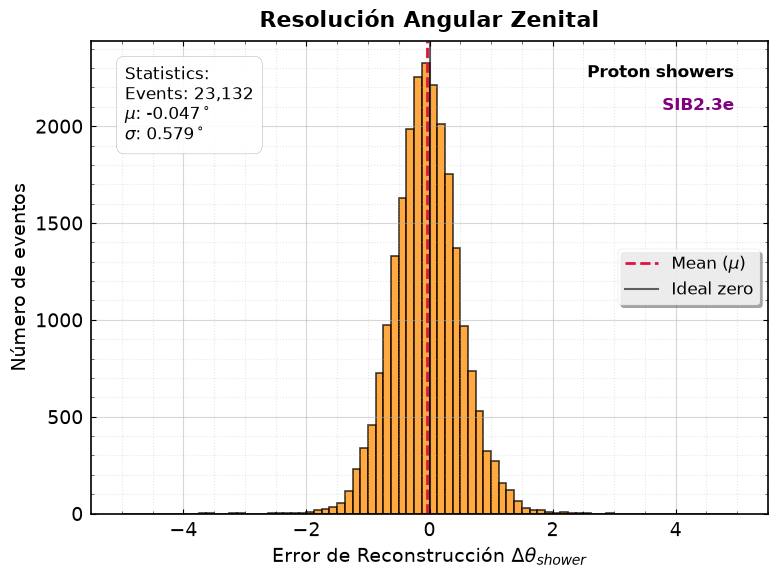

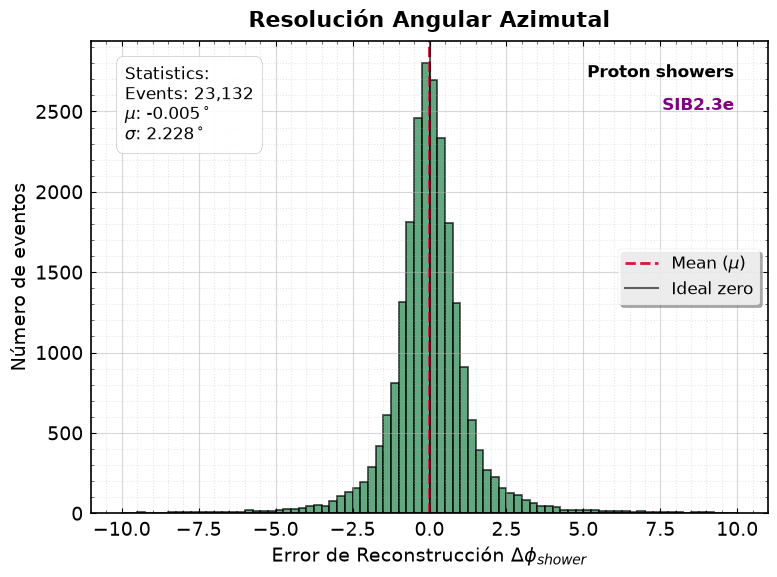

In [7]:
# =========================================================================
# CELDA: RESOLUCIÓN ANGULAR (THETA Y PHI) - HÍBRIDO HEP + GRILLAS (INGLÉS)
# =========================================================================

# Preparar datos (1 fila por evento para no sobredimensionar la estadística con los módulos)
events_guia = df_guia[['event_id', 'theta_MC', 'theta_REC', 'phi_MC', 'phi_REC']].drop_duplicates()

# Calcular errores (residuos). Para phi se ajusta el wrap-around de 360 grados.
delta_theta = events_guia['theta_REC'] - events_guia['theta_MC']
delta_phi = (events_guia['phi_REC'] - events_guia['phi_MC'] + 180) % 360 - 180

# -------------------------------------------------------------------------
# PLOT 1: Sesgo Sistemático en Ángulo Cenital (Theta)
# -------------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(8, 6))

ax1.hist(delta_theta, bins=80, range=(-5, 5), color='darkorange', edgecolor='black', linewidth=1.2, alpha=0.75)

mean_th = delta_theta.mean()
std_th = delta_theta.std()

ax1.axvline(mean_th, color='crimson', linestyle='--', linewidth=2.0, label=r'Mean ($\mu$)')
ax1.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.6, label='Ideal zero')

# Textos y etiquetas
ax1.set_xlabel(r'Error de Reconstrucción $\Delta \theta_{shower}$', fontsize=14)
ax1.set_ylabel('Número de eventos', fontsize=14)
ax1.set_title('Resolución Angular Zenital', fontsize=16, pad=10, fontweight='bold')

# Globo de estadísticas
stats_text_th = f"Statistics:\nEvents: {len(delta_theta):,}\n$\mu$: {mean_th:.3f}$^\circ$\n$\sigma$: {std_th:.3f}$^\circ$"
props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray')
ax1.text(0.05, 0.95, stats_text_th, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Anotación física
ax1.text(0.95, 0.95, r"$\mathbf{Proton\ showers}$", transform=ax1.transAxes, fontsize=12, va='top', ha='right')
ax1.text(0.95, 0.88, r"$\mathbf{SIB2.3e}$", transform=ax1.transAxes, fontsize=12, va='top', ha='right', color='purple')

# Grillas
ax1.grid(True, which='major', linestyle='-', alpha=0.5)
ax1.grid(True, which='minor', linestyle=':', alpha=0.3)
ax1.minorticks_on()

ax1.legend(loc='center right', fontsize=12)

plt.tight_layout()
plt.savefig('theta_bias.pdf', dpi=300)
plt.show()

# -------------------------------------------------------------------------
# PLOT 2: Sesgo Sistemático en Ángulo Azimutal (Phi)
# -------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 6))

ax2.hist(delta_phi, bins=80, range=(-10, 10), color='seagreen', edgecolor='black', linewidth=1.2, alpha=0.75)

mean_ph = delta_phi.mean()
std_ph = delta_phi.std()

ax2.axvline(mean_ph, color='crimson', linestyle='--', linewidth=2.0, label=r'Mean ($\mu$)')
ax2.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.6, label='Ideal zero')

# Textos y etiquetas
ax2.set_xlabel(r'Error de Reconstrucción $\Delta \phi_{shower}$', fontsize=14)
ax2.set_ylabel('Número de eventos', fontsize=14)
ax2.set_title('Resolución Angular Azimutal', fontsize=16, pad=10, fontweight='bold')

# Globo de estadísticas
stats_text_ph = f"Statistics:\nEvents: {len(delta_phi):,}\n$\mu$: {mean_ph:.3f}$^\circ$\n$\sigma$: {std_ph:.3f}$^\circ$"
ax2.text(0.05, 0.95, stats_text_ph, transform=ax2.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Anotación física
ax2.text(0.95, 0.95, r"$\mathbf{Proton\ showers}$", transform=ax2.transAxes, fontsize=12, va='top', ha='right')
ax2.text(0.95, 0.88, r"$\mathbf{SIB2.3e}$", transform=ax2.transAxes, fontsize=12, va='top', ha='right', color='purple')

# Grillas
ax2.grid(True, which='major', linestyle='-', alpha=0.5)
ax2.grid(True, which='minor', linestyle=':', alpha=0.3)
ax2.minorticks_on()

ax2.legend(loc='center right', fontsize=12)

plt.tight_layout()
plt.savefig('phi_bias.pdf', dpi=300)
plt.show()

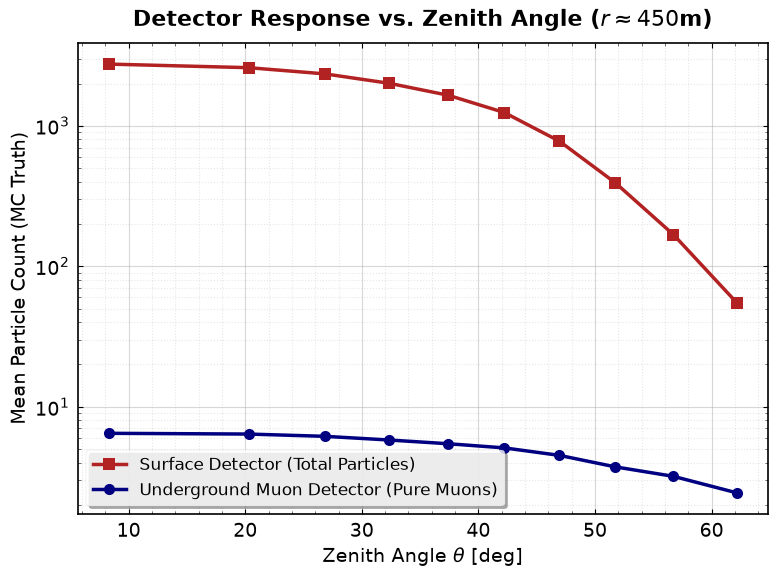

In [8]:
# =========================================================================
# PLOT 1 REEMPLAZADO: ATENUACIÓN UMD vs SD (Anillo Denso ~450m)
# =========================================================================
# 1. Filtrar solo el Anillo Denso (90k)
df_dense = df_guia[(df_guia['counterId'] >= 90000) & (df_guia['counterId'] < 100000)].copy()

# 2. Preparar los bines de Theta
s2_bins = np.linspace(np.sin(np.deg2rad(0))**2, np.sin(np.deg2rad(65))**2, 11)
theta_edges = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))
theta_centers = (theta_edges[:-1] + theta_edges[1:]) / 2

df_dense['theta_bin_idx'] = pd.cut(df_dense['theta_REC'], bins=theta_edges, labels=False)

# 3. Calcular la media y sumar para tener el SD Total
comp_theta = df_dense.groupby('theta_bin_idx', observed=True)[['nMuones_MC', 'sd_nEM_MC', 'sd_nMuons_MC']].mean().dropna()

# Crear la variable "Total SD" sumando la parte EM y la parte muónica
comp_theta['sd_Total_MC'] = comp_theta['sd_nEM_MC'] + comp_theta['sd_nMuons_MC']

valid_idx = comp_theta.index.astype(int)
x_vals = theta_centers[valid_idx]

# 4. Graficar
fig1, ax1 = plt.subplots(figsize=(8, 6))

# Señal Total del SD (Superficie)
ax1.plot(x_vals, comp_theta['sd_Total_MC'], 's-', color='firebrick', 
         label='Surface Detector (Total Particles)', lw=2.5, markersize=8)

# Señal del UMD (Enterrado)
ax1.plot(x_vals, comp_theta['nMuones_MC'], 'o-', color='navy', 
         label='Underground Muon Detector (Pure Muons)', lw=2.5, markersize=8)

ax1.set_xlabel(r'Zenith Angle $\theta$ [deg]', fontsize=14)
ax1.set_ylabel('Mean Particle Count (MC Truth)', fontsize=14)
ax1.set_yscale('log')
ax1.set_title(r'Detector Response vs. Zenith Angle ($r \approx 450$m)', fontsize=16, fontweight='bold', pad=12)

# Estética HEP
ax1.grid(True, which='major', linestyle='-', alpha=0.5)
ax1.grid(True, which='minor', linestyle=':', alpha=0.3)
ax1.minorticks_on()
ax1.legend(fontsize=12, loc='lower left')

plt.tight_layout()
plt.savefig('detectore_response.jpg')
plt.show()

guardado


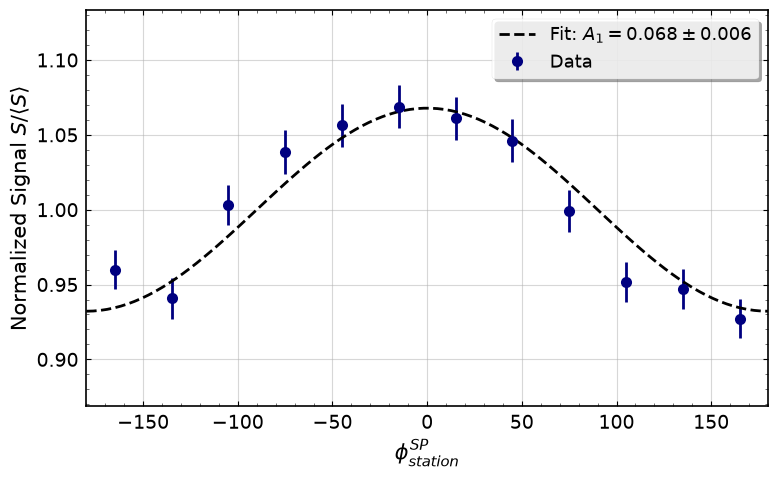

guardado


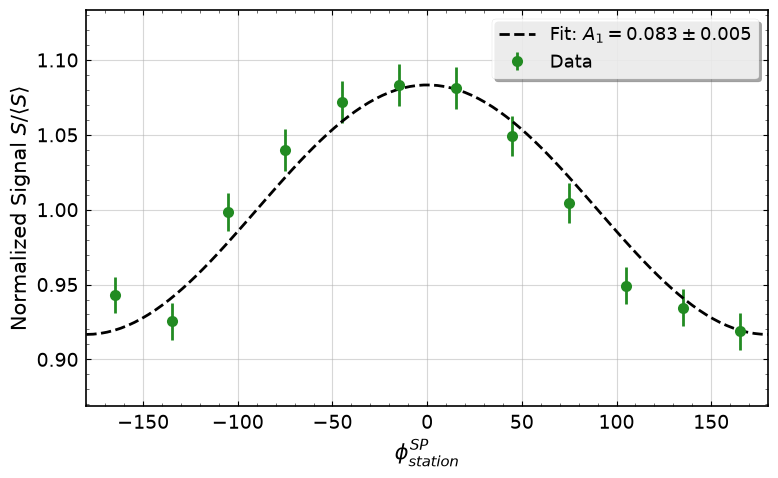

guardado


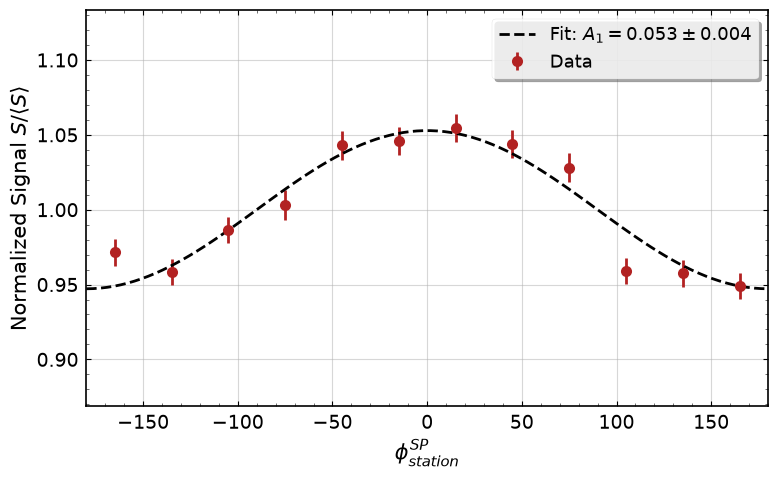

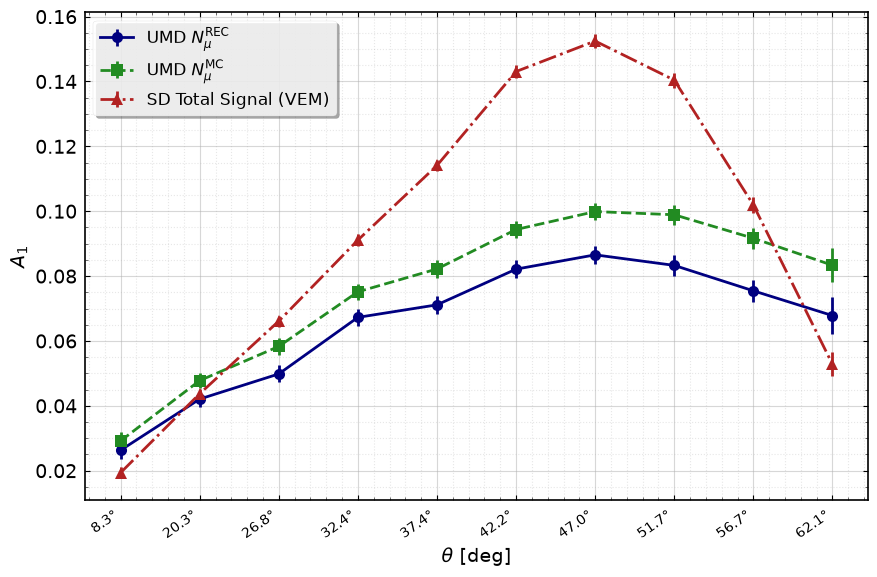

In [8]:
# -------------------------------------------------------------------------
# PREPARACIÓN DE BINES PARA PLOTS 2 Y 3
# -------------------------------------------------------------------------
s2_bins = np.linspace(np.sin(np.deg2rad(0))**2, np.sin(np.deg2rad(65))**2, 11)
df_guia['theta_bin_idx'] = pd.cut(df_guia['theta_REC'], bins=np.rad2deg(np.arcsin(np.sqrt(s2_bins))), labels=False)
df_ana = df_guia[(df_guia['counterId'] >= 90000) & (df_guia['counterId'] < 100000)].copy()

df_ana['phi_deg_centered'] = (np.rad2deg(df_ana['phi_plane_sp']) + 180) % 360 - 180
phi_bin_edges = np.linspace(-180, 180, 13)
phi_centers = (phi_bin_edges[:-1] + phi_bin_edges[1:]) / 2

evol_theta, evol_a1_umd_rec, evol_err_umd_rec = [], [], []
evol_a1_umd_mc, evol_err_umd_mc, evol_a1_sd, evol_err_sd = [], [], [], []

for i in range(10):
    mask_bin = (df_ana['theta_bin_idx'] == i)
    df_sl = df_ana[mask_bin].copy()
    if len(df_sl) < 50: continue
    
    df_sl['phi_bin'] = pd.cut(df_sl['phi_deg_centered'], bins=phi_bin_edges)
    stats = df_sl.groupby('phi_bin', observed=True)[['nMuones_REC', 'nMuones_MC', 'sdSignal_REC']].agg(['mean', 'sem', 'count'])
    
    plot_this_bin = (i == 9) 
        
    a1_vals, err_vals = {}, {}
    
    # ---------------------------------------------------------------------
    # PLOT 2: TIRA DE AJUSTES SEPARADOS (BIN 9)
    # ---------------------------------------------------------------------
    if plot_this_bin:
        # Calcular límites Y consistentes para que los 3 gráficos sean comparables
        y_min, y_max = 1.0, 1.0
        for col in ['nMuones_REC', 'nMuones_MC', 'sdSignal_REC']:
            if col in stats.columns:
                means = stats[col]['mean'].dropna()
                norm = means.mean()
                if norm > 0:
                    y_min = min(y_min, (means.min() / norm) - 0.05)
                    y_max = max(y_max, (means.max() / norm) + 0.05)

    configs = [
        ('nMuones_REC', r'$N_\mu^{\mathrm{REC}}$ (UMD)', 'navy', 'Ajuste_UMD_REC_Bin9.pdf'), 
        ('nMuones_MC', r'$N_\mu^{\mathrm{MC}}$ (UMD)', 'forestgreen', 'Ajuste_UMD_MC_Bin9.pdf'), 
        ('sdSignal_REC', 'Total Signal (SD)', 'firebrick', 'Ajuste_SD_Total_Bin9.pdf')
    ]

    for ax_idx, (col, label, color, filename) in enumerate(configs):
        if col not in stats.columns: continue
        means = stats[col]['mean']
        norm = means.mean()
        if pd.isna(norm) or norm == 0: continue
        y = means / norm
        yerr = (stats[col]['sem'] / norm)
        
        try:
            popt, pcov = curve_fit(fit_func_deg, phi_centers, y, p0=[0.05], sigma=yerr, absolute_sigma=True)
            A1, A1_err = popt[0], np.sqrt(pcov[0,0])
            a1_vals[col], err_vals[col] = A1, A1_err
            
            if plot_this_bin:
                # CREAR FIGURA INDIVIDUAL PARA CADA DETECTOR
                fig, ax = plt.subplots(figsize=(8, 5))
                
                ax.errorbar(phi_centers, y, yerr=yerr, fmt='o', color=color, label='Data', capsize=5)
                x_fit = np.linspace(-180, 180, 100)
                ax.plot(x_fit, fit_func_deg(x_fit, A1), 'k--', lw=2, label=rf'Fit: $A_1 = {A1:.3f} \pm {A1_err:.3f}$')
                
                ax.set_xlim(-180, 180)
                ax.set_ylim(y_min, y_max)  # Forzar misma escala en los 3 plots
                ax.grid(True, which='major', linestyle='-', alpha=0.5)
                ax.legend(fontsize=13, loc='upper right')
                
                # Poner labels a todos para que tengan sentido individualmente
                ax.set_ylabel(r"Normalized Signal $S / \langle S \rangle$", fontsize=15)
                ax.set_xlabel(r"$\phi^{SP}_{station}$", fontsize=15)
                
                plt.tight_layout()
                try:
                    fig.savefig(filename, dpi=300, bbox_inches='tight')
                    print('guardado')
                except: pass
                plt.show()
                
        except: pass
        
    evol_theta.append(i)
    evol_a1_umd_rec.append(a1_vals.get('nMuones_REC', np.nan))
    evol_err_umd_rec.append(err_vals.get('nMuones_REC', 0))
    evol_a1_umd_mc.append(a1_vals.get('nMuones_MC', np.nan))
    evol_err_umd_mc.append(err_vals.get('nMuones_MC', 0))
    evol_a1_sd.append(a1_vals.get('sdSignal_REC', np.nan))
    evol_err_sd.append(err_vals.get('sdSignal_REC', 0))

# -------------------------------------------------------------------------
# PLOT 3: EVOLUCIÓN A1 vs THETA
# -------------------------------------------------------------------------

# =========================================================================
# CELDA: SD vs UMD - ALL-IN-ONE MASTER PLOT (PRESENTATION STYLE)
# =========================================================================

def fit_func_deg(phi_deg, A1):
    return 1.0 * (1 + A1 * np.cos(np.deg2rad(phi_deg)))

# -------------------------------------------------------------------------
# PREPARACIÓN DE BINES
# -------------------------------------------------------------------------
s2_bins = np.linspace(np.sin(np.deg2rad(0))**2, np.sin(np.deg2rad(65))**2, 11)

# --- CÓDIGO NUEVO: Calcular bordes y armar labels ---
theta_edges = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))

theta_centers = (theta_edges[:-1] + theta_edges[1:]) / 2
theta_labels = [f"{theta:.1f}°" for theta in theta_centers]
# ----------------------------------------------------

df_guia['theta_bin_idx'] = pd.cut(df_guia['theta_REC'], bins=theta_edges, labels=False)
df_ana = df_guia[(df_guia['counterId'] >= 90000) & (df_guia['counterId'] < 100000)].copy()

# ... (El resto del for loop y cálculo de A1 queda exactamente igual) ...


fig3, ax_ev = plt.subplots(figsize=(9, 6))

ax_ev.errorbar(evol_theta, evol_a1_umd_rec, yerr=evol_err_umd_rec, fmt='o-', color='navy', label=r'UMD $N_\mu^{\mathrm{REC}}$')
ax_ev.errorbar(evol_theta, evol_a1_umd_mc, yerr=evol_err_umd_mc, fmt='s--', color='forestgreen', label=r'UMD $N_\mu^{\mathrm{MC}}$')
ax_ev.errorbar(evol_theta, evol_a1_sd, yerr=evol_err_sd, fmt='^-.', color='firebrick', label='SD Total Signal (VEM)')

# Fijamos las posiciones de los ticks en los índices (0 a 9) y aplicamos los labels rotados
ax_ev.set_xticks(evol_theta) 
ax_ev.set_xticklabels(theta_labels, rotation=35, ha='right', fontsize=10)
# --- FIN MODIFICACIÓN ---

ax_ev.set_xlabel(r"$\theta$ [deg]", fontsize=14)
ax_ev.set_ylabel(r"$A_1$", fontsize=14)

ax_ev.grid(True, which='major', linestyle='-', alpha=0.5)
ax_ev.grid(True, which='minor', linestyle=':', alpha=0.3)
ax_ev.minorticks_on()
ax_ev.legend(fontsize=12, loc='upper left')

# Indicador del detector / arreglo
ax.text(0.05, 0.20, r"$\mathbf{Dense\ Ring\ (450\ m)}$", transform=ax.transAxes, fontsize=12, va='top', ha='left', color='black')
ax.text(0.05, 0.13, r"$\mathbf{\theta \approx 40^\circ - 65^\circ}$", transform=ax.transAxes, fontsize=12, va='top', ha='left')

# Anotaciones Físicas
ax.text(0.5, 0.98, r"$\mathbf{Proton\ showers}$", transform=ax.transAxes, fontsize=12, va='top', ha='right', color=COLORS['Proton'])
ax.text(0.5, 0.91, r"$\mathbf{SIB2.3e}$", transform=ax.transAxes, fontsize=12, va='top', ha='right', color='purple')
ax.text(0.5, 0.84, r"$\log_{10}(E_0/\mathrm{eV}) = 17.5 - 18.0$", transform=ax.transAxes, fontsize=11, va='top', ha='right')


plt.tight_layout()
fig3.savefig('Evolucion_Asimetria_vs_Theta.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

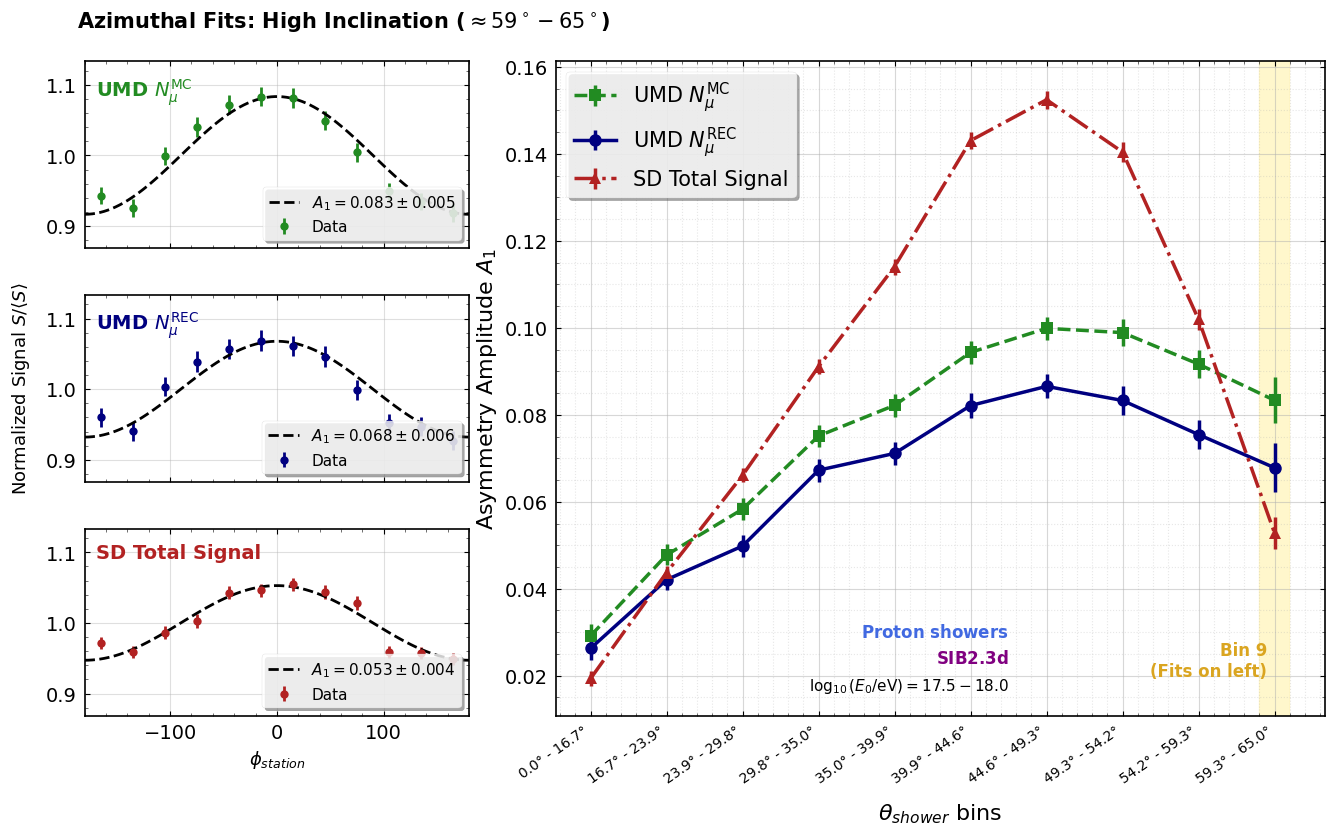

In [12]:
# =========================================================================
# CELDA: SD vs UMD - ALL-IN-ONE MASTER PLOT (PRESENTATION STYLE)
# =========================================================================

def fit_func_deg(phi_deg, A1):
    return 1.0 * (1 + A1 * np.cos(np.deg2rad(phi_deg)))

# -------------------------------------------------------------------------
# PREPARACIÓN DE BINES
# -------------------------------------------------------------------------
s2_bins = np.linspace(np.sin(np.deg2rad(0))**2, np.sin(np.deg2rad(65))**2, 11)

# --- CÓDIGO NUEVO: Calcular bordes y armar labels ---
theta_edges = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))
theta_labels = [f"{theta_edges[k]:.1f}° - {theta_edges[k+1]:.1f}°" for k in range(10)]
# ----------------------------------------------------

df_guia['theta_bin_idx'] = pd.cut(df_guia['theta_REC'], bins=theta_edges, labels=False)
df_ana = df_guia[(df_guia['counterId'] >= 90000) & (df_guia['counterId'] < 100000)].copy()

# ... (El resto del for loop y cálculo de A1 queda exactamente igual) ...

# -------------------------------------------------------------------------
# PREPARACIÓN DE BINES
# -------------------------------------------------------------------------
s2_bins = np.linspace(np.sin(np.deg2rad(0))**2, np.sin(np.deg2rad(65))**2, 11)
df_guia['theta_bin_idx'] = pd.cut(df_guia['theta_REC'], bins=np.rad2deg(np.arcsin(np.sqrt(s2_bins))), labels=False)
df_ana = df_guia[(df_guia['counterId'] >= 90000) & (df_guia['counterId'] < 100000)].copy()

df_ana['phi_deg_centered'] = (np.rad2deg(df_ana['phi_plane_sp']) + 180) % 360 - 180
phi_bin_edges = np.linspace(-180, 180, 13)
phi_centers = (phi_bin_edges[:-1] + phi_bin_edges[1:]) / 2

evol_theta, evol_a1_umd_rec, evol_err_umd_rec = [], [], []
evol_a1_umd_mc, evol_err_umd_mc, evol_a1_sd, evol_err_sd = [], [], [], []

# Variables para guardar los datos del Bin 9 y plotearlos después
bin9_data = {}

for i in range(10):
    mask_bin = (df_ana['theta_bin_idx'] == i)
    df_sl = df_ana[mask_bin].copy()
    if len(df_sl) < 50: continue
    
    df_sl['phi_bin'] = pd.cut(df_sl['phi_deg_centered'], bins=phi_bin_edges)
    stats = df_sl.groupby('phi_bin', observed=True)[['nMuones_REC', 'nMuones_MC', 'sdSignal_REC']].agg(['mean', 'sem', 'count'])
    
    a1_vals, err_vals = {}, {}
    
    for col in ['nMuones_REC', 'nMuones_MC', 'sdSignal_REC']:
        if col not in stats.columns: continue
        means = stats[col]['mean']
        norm = means.mean()
        if pd.isna(norm) or norm == 0: continue
        y = means / norm
        yerr = (stats[col]['sem'] / norm)
        
        try:
            popt, pcov = curve_fit(fit_func_deg, phi_centers, y, p0=[0.05], sigma=yerr, absolute_sigma=True)
            A1, A1_err = popt[0], np.sqrt(pcov[0,0])
            a1_vals[col], err_vals[col] = A1, A1_err
            
            # Si es el Bin 9, guardamos los datos crudos para plotear a la izquierda
            if i == 9:
                bin9_data[col] = {'y': y, 'yerr': yerr, 'A1': A1, 'A1_err': A1_err}
        except: pass
        
    evol_theta.append(i)
    evol_a1_umd_rec.append(a1_vals.get('nMuones_REC', np.nan))
    evol_err_umd_rec.append(err_vals.get('nMuones_REC', 0))
    evol_a1_umd_mc.append(a1_vals.get('nMuones_MC', np.nan))
    evol_err_umd_mc.append(err_vals.get('nMuones_MC', 0))
    evol_a1_sd.append(a1_vals.get('sdSignal_REC', np.nan))
    evol_err_sd.append(err_vals.get('sdSignal_REC', 0))

# -------------------------------------------------------------------------
# ARMADO DE LA FIGURA MAESTRA (16:9 ratio)
# -------------------------------------------------------------------------
fig = plt.figure(figsize=(16, 8.5))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 2], wspace=0.15, hspace=0.25)

# --- PANEL IZQUIERDO: LOS 3 AJUSTES DEL BIN 9 ---
# Para que se vean comparables, buscamos el max/min del eje Y del Bin 9
y_min_g, y_max_g = 1.0, 1.0
for col, d in bin9_data.items():
    y_min_g = min(y_min_g, min(d['y']) - 0.05)
    y_max_g = max(y_max_g, max(d['y']) + 0.05)

configs = [
    ('nMuones_MC', r'UMD $N_\mu^{\mathrm{MC}}$', 'forestgreen', gs[0, 0]),
    ('nMuones_REC', r'UMD $N_\mu^{\mathrm{REC}}$', 'navy', gs[1, 0]), 
    ('sdSignal_REC', r'SD Total Signal', 'firebrick', gs[2, 0])
]

axes_izq = []
for idx, (col, label, color, pos) in enumerate(configs):
    ax = fig.add_subplot(pos)
    axes_izq.append(ax)
    
    if col in bin9_data:
        d = bin9_data[col]
        ax.errorbar(phi_centers, d['y'], yerr=d['yerr'], fmt='o', color=color, label='Data', capsize=4, markersize=6)
        x_fit = np.linspace(-180, 180, 100)
        ax.plot(x_fit, fit_func_deg(x_fit, d['A1']), 'k--', lw=2, label=rf'$A_1 = {d["A1"]:.3f} \pm {d["A1_err"]:.3f}$')
        
        # Estética de cada sub-plot
        ax.set_ylim(y_min_g, y_max_g)
        ax.set_xlim(-180, 180)
        ax.grid(True, which='major', linestyle='-', alpha=0.4)
        
        # Título como texto adentro para ahorrar espacio
        ax.text(0.03, 0.92, label, transform=ax.transAxes, fontsize=14, fontweight='bold', color=color, va='top')
        ax.legend(fontsize=11, loc='lower right')
        
        if idx == 1: # Solo el del medio tiene label de Y
            ax.set_ylabel(r"Normalized Signal $S / \langle S \rangle$", fontsize=13, labelpad=10)
        
        if idx == 2: # Solo el de abajo tiene label de X
            ax.set_xlabel(r"$\phi_{station}$", fontsize=13)
        else:
            ax.set_xticklabels([]) # Ocultar números X en los de arriba

# Título general para la columna izquierda
fig.text(0.12, 0.92, r"Azimuthal Fits: High Inclination ($\approx 59^\circ-65^\circ$)", 
         fontsize=15, fontweight='bold', ha='left')

# --- PANEL DERECHO: EVOLUCIÓN GLOBAL ---
ax_ev = fig.add_subplot(gs[:, 1]) # Ocupa todas las filas de la columna 1

ax_ev.errorbar(evol_theta, evol_a1_umd_mc, yerr=evol_err_umd_mc, fmt='s--', color='forestgreen', label=r'UMD $N_\mu^{\mathrm{MC}}$', markersize=9, lw=2.5)
ax_ev.errorbar(evol_theta, evol_a1_umd_rec, yerr=evol_err_umd_rec, fmt='o-', color='navy', label=r'UMD $N_\mu^{\mathrm{REC}}$', markersize=9, lw=2.5)
ax_ev.errorbar(evol_theta, evol_a1_sd, yerr=evol_err_sd, fmt='^-.', color='firebrick', label='SD Total Signal', markersize=9, lw=2.5)

# --- INICIO MODIFICACIÓN DEL EJE X ---
ax_ev.set_xlabel(r"$\theta_{shower}$ bins", fontsize=16, labelpad=11)

# Fijamos las posiciones de los ticks en los índices (0 a 9) y aplicamos los labels rotados
ax_ev.set_xticks(evol_theta) 
ax_ev.set_xticklabels(theta_labels, rotation=35, ha='right', fontsize=10)
# --- FIN MODIFICACIÓN ---

ax_ev.set_ylabel(r"Asymmetry Amplitude $A_1$", fontsize=16)

ax_ev.grid(True, which='major', linestyle='-', alpha=0.5)
ax_ev.grid(True, which='minor', linestyle=':', alpha=0.3)
ax_ev.minorticks_on()
ax_ev.legend(fontsize=15, loc='upper left')

# Resaltar el Bin 9 en el gráfico de evolución para conectarlo con la izquierda
ax_ev.axvspan(8.8, 9.2, color='gold', alpha=0.2, zorder=0)
ax_ev.text(8.9, 0.02, "Bin 9\n(Fits on left)", color='goldenrod', fontweight='bold', fontsize=12, ha='right')

# Anotaciones Físicas
ax_ev.text(5.5, 0.032, r"$\mathbf{Proton\ showers}$", fontsize=12, va='top', ha='right', color='royalblue') # Ajusté el color genérico
ax_ev.text(5.5, 0.026, r"$\mathbf{SIB2.3d}$", fontsize=12, va='top', ha='right', color='purple')
ax_ev.text(5.5, 0.02, r"$\log_{10}(E_0/\mathrm{eV}) = 17.5 - 18.0$", fontsize=11, va='top', ha='right')

# --- MODIFICACIÓN IMPORTANTE PARA GUARDAR ---
plt.tight_layout() 
plt.savefig('MasterPlot_Asymmetry_Evolution.jpg', bbox_inches='tight', dpi=300)
plt.show()

In [13]:
# =========================================================================
# PROCESAMIENTO: CÁLCULO DE A1 PARA CADA BIN DE ENERGÍA Y AZIMUT
# =========================================================================

# 1. Filtro para el Anillo Denso (Dense Ring)
df_dense = df_guia[(df_guia['counterId'] < 100000) & 
                  (df_guia['theta_REC'] > 40) & (df_guia['theta_REC'] < 60)].copy()

# Pre-procesamiento de Phi Plane (necesario para la función get_a1)
df_dense['phi_deg_centered'] = (np.rad2deg(df_dense['phi_plane_sp']) + 180) % 360 - 180
df_dense['phi_bin'] = pd.cut(df_dense['phi_deg_centered'], bins=phi_bin_edges)

# --- FUNCIÓN ADAPTADA PARA HACER FIT DE REC Y MC ---
def get_a1_custom(sub_df, column):
    prof = sub_df.groupby('phi_bin', observed=True)[column].agg(['mean', 'sem']).dropna()
    if len(prof) < 8: return np.nan, np.nan
    norm = prof['mean'].mean()
    if norm == 0: return np.nan, np.nan
    try:
        popt, pcov = curve_fit(fit_func_deg, phi_centers, prof['mean']/norm, 
                               p0=[0.05], sigma=prof['sem']/norm, absolute_sigma=True)
        return popt[0], np.sqrt(pcov[0,0])
    except:
        return np.nan, np.nan

# --- PROCESAMIENTO 1: ENERGÍA ---
e_bins = np.linspace(17.5, 18.0, 6)
e_cents = (e_bins[:-1] + e_bins[1:]) / 2
df_dense['e_bin_idx'] = pd.cut(df_dense['logE_REC'], bins=e_bins, labels=False)

res_en = {'rec': [], 'rec_err': [], 'mc': [], 'mc_err': []}
for b in range(len(e_bins)-1):
    sub = df_dense[df_dense['e_bin_idx'] == b]
    a1_r, e_r = get_a1_custom(sub, 'nMuones_REC')
    a1_m, e_m = get_a1_custom(sub, 'nMuones_MC')
    res_en['rec'].append(a1_r); res_en['rec_err'].append(e_r)
    res_en['mc'].append(a1_m); res_en['mc_err'].append(e_m)

# --- PROCESAMIENTO 2: ISOTROPÍA (Azimut de entrada) ---
# Usamos phi_REC como proxy de phi_in si no está la columna
phi_col = 'phi_in' if 'phi_in' in df_dense.columns else 'phi_REC'
df_dense['phi_in_deg'] = ensure_degrees(df_dense[phi_col])
phi_in_bins = np.linspace(0, 360, 7)
phi_in_cents = (phi_in_bins[:-1] + phi_in_bins[1:]) / 2
df_dense['phi_in_bin_idx'] = pd.cut(df_dense['phi_in_deg'], bins=phi_in_bins, labels=False)

res_iso = {'rec': [], 'rec_err': [], 'mc': [], 'mc_err': []}
for b in range(len(phi_in_bins)-1):
    sub = df_dense[df_dense['phi_in_bin_idx'] == b]
    a1_r, e_r = get_a1_custom(sub, 'nMuones_REC')
    a1_m, e_m = get_a1_custom(sub, 'nMuones_MC')
    res_iso['rec'].append(a1_r); res_iso['rec_err'].append(e_r)
    res_iso['mc'].append(a1_m); res_iso['mc_err'].append(e_m)

print("✅ Fits completados. res_en y res_iso listos para graficar.")

✅ Fits completados. res_en y res_iso listos para graficar.


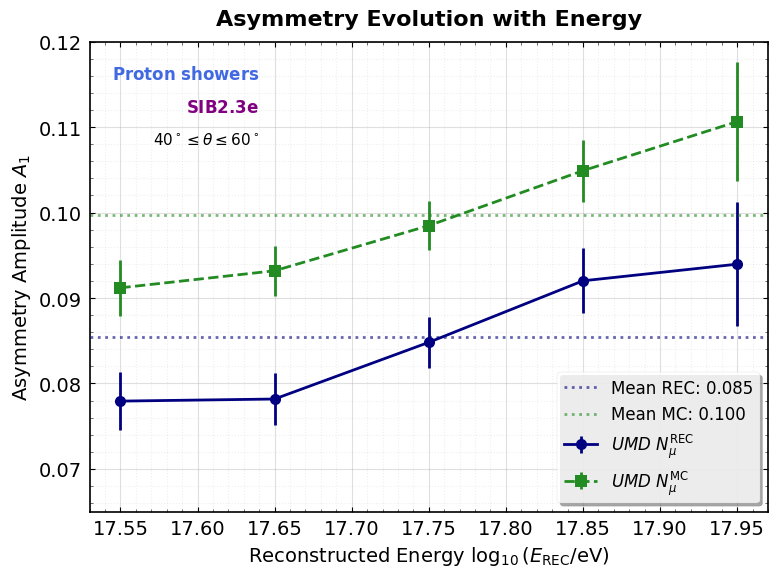

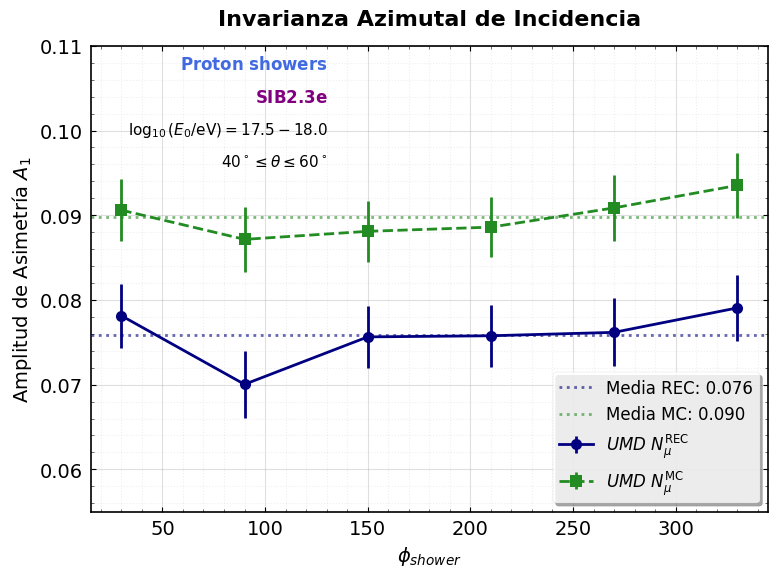

In [16]:
# =========================================================================
# PLOT 1: DEPENDENCIA DE ENERGÍA (Estilo Auger)
# =========================================================================
fig_e, ax_e = plt.subplots(figsize=(8, 6))

# Graficamos los datos
ax_e.errorbar(e_cents, res_en['rec'], yerr=res_en['rec_err'], fmt='o-', 
              label=r'$UMD\ N_\mu^{\mathrm{REC}}$', color='navy', mfc='navy', lw=2, markersize=8, capsize=4)
ax_e.errorbar(e_cents, res_en['mc'], yerr=res_en['mc_err'], fmt='s--', 
              label=r'$UMD\ N_\mu^{\mathrm{MC}}$', color='forestgreen', mfc='forestgreen', lw=2, markersize=8, capsize=4)

# Líneas medias para guiar el ojo
valid_rec = [x for x in res_en['rec'] if not np.isnan(x)]
valid_mc = [x for x in res_en['mc'] if not np.isnan(x)]
if valid_rec: ax_e.axhline(np.mean(valid_rec), color='navy', linestyle=':', alpha=0.6, lw=2, label=rf'Mean REC: {np.mean(valid_rec):.3f}')
if valid_mc: ax_e.axhline(np.mean(valid_mc), color='forestgreen', linestyle=':', alpha=0.6, lw=2, label=rf'Mean MC: {np.mean(valid_mc):.3f}')

# Textos y etiquetas
ax_e.set_xlabel(r"Reconstructed Energy $\log_{10}(E_{\mathrm{REC}}/\mathrm{eV})$", fontsize=14)
ax_e.set_ylabel(r"Asymmetry Amplitude $A_1$", fontsize=14)
ax_e.set_title("Asymmetry Evolution with Energy", fontsize=16, fontweight='bold', pad=12)


# Anotaciones Físicas (Top Right, flotantes)
ax_e.text(0.25, 0.95, r"$\mathbf{Proton\ showers}$", transform=ax_e.transAxes, fontsize=12, va='top', ha='right', color='royalblue')
ax_e.text(0.25, 0.88, r"$\mathbf{SIB2.3e}$", transform=ax_e.transAxes, fontsize=12, va='top', ha='right', color='purple')
ax_e.text(0.25, 0.81, r"$40^\circ \leq \theta \leq 60^\circ$", transform=ax_e.transAxes, fontsize=11, va='top', ha='right')

# Leyenda y Grillas
ax_e.legend(fontsize=12, loc='lower right')
ax_e.set_ylim(0.065, 0.12) 
ax_e.grid(True, which='major', linestyle='-', alpha=0.4)
ax_e.grid(True, which='minor', linestyle=':', alpha=0.2)
ax_e.minorticks_on()

plt.tight_layout()
plt.savefig('DenseRing_Systematics_Energy.jpg', format='jpg', dpi=600, bbox_inches='tight')
plt.show()

# =========================================================================
# PLOT 2: INVARIANZA AZIMUTAL (Estilo Auger)
# =========================================================================
fig_i, ax_i = plt.subplots(figsize=(8, 6))

# Graficamos los datos
ax_i.errorbar(phi_in_cents, res_iso['rec'], yerr=res_iso['rec_err'], fmt='o-', 
              color='navy', mfc='navy', label=r'$UMD\ N_\mu^{\mathrm{REC}}$', lw=2, markersize=8, capsize=4)
ax_i.errorbar(phi_in_cents, res_iso['mc'], yerr=res_iso['mc_err'], fmt='s--', 
              color='forestgreen', mfc='forestgreen', label=r'$UMD\ N_\mu^{\mathrm{MC}}$', lw=2, markersize=8, capsize=4)

# Líneas punteadas de las medias
vr_iso = [x for x in res_iso['rec'] if not np.isnan(x)]
vm_iso = [x for x in res_iso['mc'] if not np.isnan(x)]
if vr_iso: ax_i.axhline(np.mean(vr_iso), color='navy', linestyle=':', alpha=0.6, lw=2, label=rf'Media REC: {np.mean(vr_iso):.3f}')
if vm_iso: ax_i.axhline(np.mean(vm_iso), color='forestgreen', linestyle=':', alpha=0.6, lw=2, label=rf'Media MC: {np.mean(vm_iso):.3f}')

# Textos y etiquetas
ax_i.set_xlabel(r"$\phi_{shower}$", fontsize=14)
ax_i.set_ylabel(r"Amplitud de Asimetría $A_1$", fontsize=14)
ax_i.set_title(r"Invarianza Azimutal de Incidencia", fontsize=16, fontweight='bold', pad=15)

# Anotaciones Físicas (Top Right, flotantes)
ax_i.text(0.35, 0.98, r"$\mathbf{Proton\ showers}$", transform=ax_i.transAxes, fontsize=12, va='top', ha='right', color='royalblue')
ax_i.text(0.35, 0.91, r"$\mathbf{SIB2.3e}$", transform=ax_i.transAxes, fontsize=12, va='top', ha='right', color='purple')
ax_i.text(0.35, 0.84, r"$\log_{10}(E_0/\mathrm{eV}) = 17.5 - 18.0$", transform=ax_i.transAxes, fontsize=11, va='top', ha='right')
ax_i.text(0.35, 0.77, r"$40^\circ \leq \theta \leq 60^\circ$", transform=ax_i.transAxes, fontsize=11, va='top', ha='right')

# Leyenda y Grillas
ax_i.legend(fontsize=12, loc='lower right')
ax_i.set_ylim(0.055, 0.11) 
ax_i.grid(True, which='major', linestyle='-', alpha=0.4)
ax_i.grid(True, which='minor', linestyle=':', alpha=0.2)
ax_i.minorticks_on()

plt.tight_layout()
plt.savefig('DenseRing_Systematics_Isotropy.jpg', format='jpg', dpi=600, bbox_inches='tight')
plt.show()

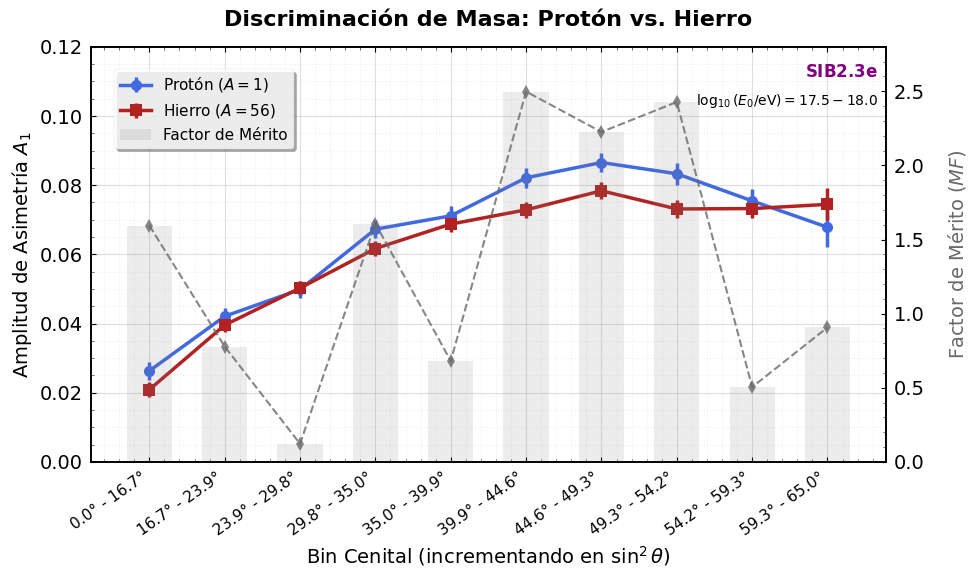

In [75]:
# =========================================================================
# CELDA: DISCRIMINACIÓN DE MASA Y FACTOR DE MÉRITO (MONEY PLOT)
# =========================================================================

# Filtrado de datos para el dataset guía (Ej: SIBYLL 17.5-18.0)
df_money = df_res[(df_res['Model'] == 'SIBYLL') & (df_res['Energy'] == '17.5-18.0')].copy()

# Separamos los datos
p_data = df_money[df_money['Primary'] == 'Proton'].sort_values('ThetaBin')
fe_data = df_money[df_money['Primary'] == 'Hierro'].sort_values('ThetaBin')

# Cálculo del Factor de Mérito (MF)
# MF = |mu1 - mu2| / sqrt(sigma1^2 + sigma2^2)
mf = np.abs(p_data['A1'].values - fe_data['A1'].values) / np.sqrt(p_data['Err'].values**2 + fe_data['Err'].values**2)

# --- INICIO DEL PLOT ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje Izquierdo: Amplitudes A1
ax1.errorbar(p_data['ThetaBin'], p_data['A1'], yerr=p_data['Err'], fmt='o-', 
             color='royalblue', label=r'Protón ($A=1$)', lw=2.5, markersize=8, capsize=4)
ax1.errorbar(fe_data['ThetaBin'], fe_data['A1'], yerr=fe_data['Err'], fmt='s-', 
             color='firebrick', label=r'Hierro ($A=56$)', lw=2.5, markersize=8, capsize=4)

# Eje Derecho: Factor de Mérito
ax2 = ax1.twinx()
ax2.bar(p_data['ThetaBin'], mf, alpha=0.15, color='gray', label='Factor de Mérito', width=0.6)
ax2.plot(p_data['ThetaBin'], mf, 'd--', color='dimgray', alpha=0.8, markersize=7, lw=1.5)

# --- Títulos, Etiquetas y Límites ---
ax1.set_xlabel(r"Bin Cenital (incrementando en $\sin^2\theta$)", fontsize=14)
ax1.set_ylabel(r"Amplitud de Asimetría $A_1$", fontsize=14)
ax2.set_ylabel(r"Factor de Mérito ($MF$)", fontsize=14, color='dimgray', labelpad=15)

ax1.set_title("Discriminación de Masa: Protón vs. Hierro", fontsize=16, fontweight='bold', pad=15)

# Límites en Y (Damos margen superior para que entren los textos flotantes)
ax1.set_ylim(0, 0.12)
ax2.set_ylim(0, 2.8)

# Aplicar las etiquetas de los rangos de theta al eje X
ax1.set_xticks(p_data['ThetaBin'])
ax1.set_xticklabels(theta_labels, rotation=35, ha='right', fontsize=11)

# --- Anotaciones Físicas (Estilo Auger) ---
ax1.text(0.99, 0.96, r"$\mathbf{SIB2.3e}$", transform=ax1.transAxes, fontsize=12, va='top', ha='right', color='purple')
ax1.text(0.99, 0.89, r"$\log_{10}(E_0/\mathrm{eV}) = 17.5 - 18.0$", transform=ax1.transAxes, fontsize=10, va='top', ha='right')

# --- Unificación de Leyendas ---
# Extraemos los handles de ambos ejes y los juntamos en uno solo
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center left', fontsize=11, bbox_to_anchor=(0.02, 0.85))

# Estética de grillas
ax1.grid(True, which='major', linestyle='-', alpha=0.4)
ax1.grid(True, which='minor', linestyle=':', alpha=0.2)
ax1.minorticks_on()

plt.tight_layout()
plt.savefig('Mass_Discrimination_MF.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# =========================================================================
# PREPARACIÓN: CÁLCULO DE MERIT FACTOR (MF) POR BIN
# =========================================================================

# 1. Filtramos df_res para un modelo y energía específicos (el "Money Plot")
# Usamos SIBYLL 17.5-18.0 como referencia estándar de tu tesis
money_data = df_res[(df_res['Model'] == 'SIBYLL') & (df_res['Energy'] == '17.5-18.0')].copy()

# 2. Separamos las estadísticas de Protón e Hierro
p_stats = money_data[money_data['Primary'] == 'Proton'].set_index('ThetaBin')
fe_stats = money_data[money_data['Primary'] == 'Hierro'].set_index('ThetaBin')

# 3. Encontramos los bines que tienen datos para ambos (la intersección)
common = np.intersect1d(p_stats.index, fe_stats.index) # <--- AQUÍ SE DEFINE 'common'

# 4. Calculamos el Merit Factor para cada uno de esos bines
mf_vals = []
for b in common:
    mf = calc_mf(p_stats.loc[b, 'A1'], p_stats.loc[b, 'Err'],
                 fe_stats.loc[b, 'A1'], fe_stats.loc[b, 'Err'])
    mf_vals.append(mf)

mf_vals = np.array(mf_vals) # <--- AQUÍ SE DEFINE 'mf_vals'

print(f"✅ MF calculado para {len(common)} bines. Máximo MF: {np.max(mf_vals):.2f}")

✅ MF calculado para 10 bines. Máximo MF: 2.50


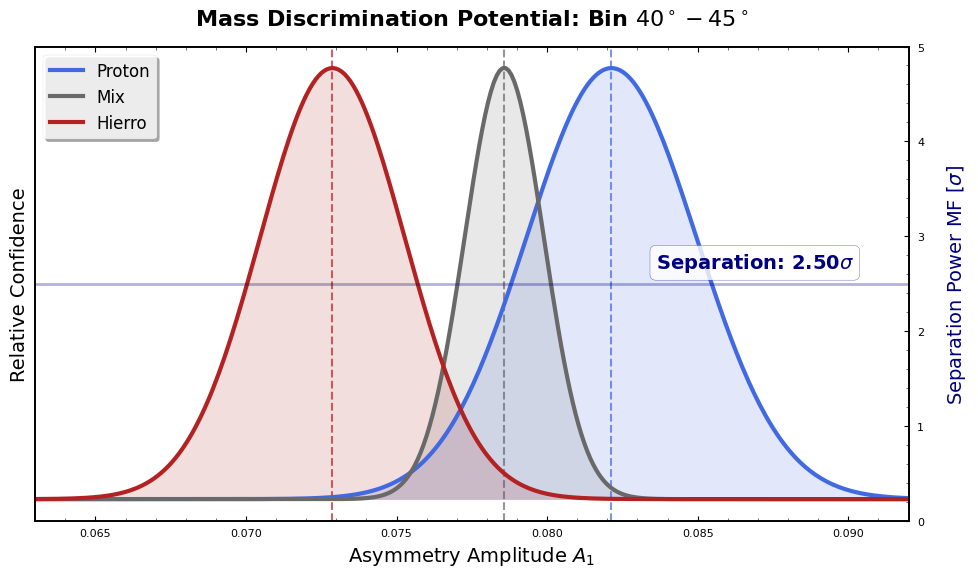

In [23]:
# =========================================================================
# CELDA: DISCRIMINACIÓN DE MASA (GAUSSIANAS NIVELADAS AL PICO)
# =========================================================================

from scipy.stats import norm

# 1. Parámetros del Bin Óptimo
idx_max = np.argmax(mf_vals)
max_bin = int(common[idx_max])

mus, sigs, labs, cols = [], [], [], []
proton_stats, iron_stats = None, None

for p in ['Proton', 'Mix', 'Hierro']:
    r = money_data[(money_data['Primary'] == p) & (money_data['ThetaBin'] == max_bin)]
    if not r.empty:
        m, s = r['A1'].values[0], r['Err'].values[0]
        mus.append(m); sigs.append(s); labs.append(p); cols.append(COLORS.get(p))
        if p == 'Proton': proton_stats = (m, s)
        if p == 'Hierro': iron_stats = (m, s)

# 2. Función de graficado con Normalización al Pico (Height=1)
def plot_peak_normalized_gaussians(ax, mus, sigs, labels, colors, title):
    # Definimos el rango del eje X
    x_min = min(mus) - 3.5*max(sigs)
    x_max = max(mus) + 3.5*max(sigs)
    x = np.linspace(x_min, x_max, 300)
    
    for mu, sig, lab, col in zip(mus, sigs, labels, colors):
        # Calculamos la Gaussiana estándar
        y = norm.pdf(x, mu, sig)
        # NORMALIZACIÓN AL PICO: Dividimos por el valor máximo de la curva
        y_peak = y / np.max(y)
        
        # Dibujamos la curva y el área
        ax.plot(x, y_peak, color=col, lw=3, label=lab, zorder=3)
        ax.fill_between(x, y_peak, alpha=0.15, color=col, zorder=2)
        
        # LÍNEA VERTICAL AL CENTRO: Para marcar el valor medio de A1
        ax.axvline(mu, color=col, linestyle='--', lw=1.5, alpha=0.7, zorder=1)

    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel(r"Asymmetry Amplitude $A_1$", fontsize=14)
    ax.set_ylabel("Relative Confidence", fontsize=14) # Cambiamos PDF por Confianza Relativa
    ax.set_yticks([]) # Quitamos los números del eje Y porque ya no es una densidad real
    ax.legend(loc='upper left', fontsize=12, frameon=True)
    ax.set_xlim(x_min, x_max)

# 3. Ejecución del Plot
if len(mus) >= 2:
    fig_g, ax_g = plt.subplots(figsize=(10, 6))
    title_str = f"Mass Discrimination Potential: Bin {theta_labels[max_bin]}"
    
    plot_peak_normalized_gaussians(ax_g, mus, sigs, labs, cols, title_str)
    
    # Mantenemos el Merit Factor a la derecha como métrica de éxito
    mf_p_fe = np.abs(proton_stats[0] - iron_stats[0]) / np.sqrt(proton_stats[1]**2 + iron_stats[1]**2)
    ax_g2 = ax_g.twinx()
    ax_g2.set_ylim(0, 5)
    ax_g2.set_ylabel(r"Separation Power MF [$\sigma$]", color='navy', fontsize=14, labelpad=15)
    ax_g2.axhline(mf_p_fe, color='navy', linestyle='-', lw=2, alpha=0.3)
    
    # Anotación llamativa del MF
    ax_g2.text(ax_g.get_xlim()[1]*0.98, mf_p_fe + 0.1, rf"Separation: {mf_p_fe:.2f}$\sigma$", 
                ha='right', va='bottom', color='navy', fontweight='bold', fontsize=14,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='navy', alpha=0.8))

    plt.tight_layout()
    plt.savefig('Discriminacion_Masa_Limpio.jpg', dpi=300)
    plt.show()

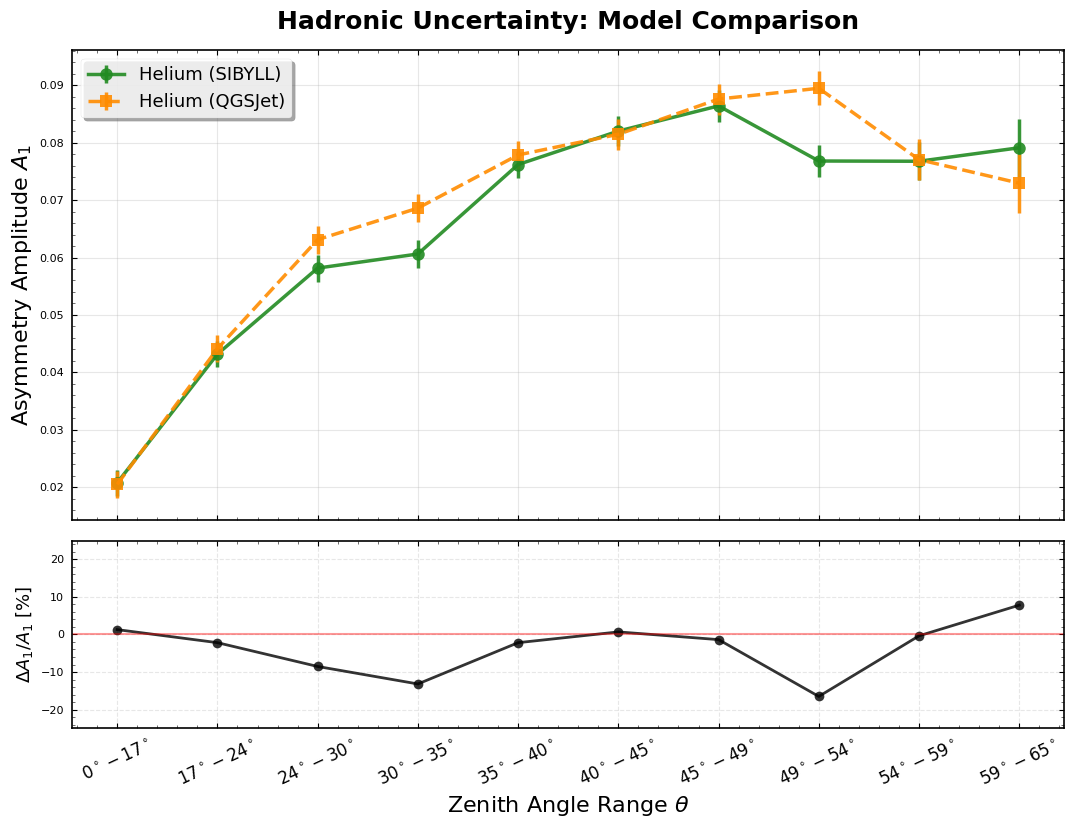

In [24]:
# =========================================================================
# CELDA: ROBUSTEZ HADRÓNICA (HELIO SIBYLL vs QGSJET)
# =========================================================================

# Diccionarios de configuración visual
LINES = {'SIBYLL': '-', 'QGSJet': '--', 'EPOS': ':'}
COLORS_MOD = {'SIBYLL': 'forestgreen', 'QGSJet': 'darkorange'}

# Filtrar Helio a energía fija (17.5-18.0)
he_data = df_res[(df_res['Primary'] == 'Helio') & 
                 (df_res['Energy'] == '17.5-18.0') & 
                 (df_res['Model'].isin(['SIBYLL', 'QGSJet']))]

# Figura de dos paneles (2 filas, 1 columna)
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(11, 8.5), sharex=True, 
                               gridspec_kw={'height_ratios': [2.5, 1]})
fig.subplots_adjust(hspace=0.08) 

# PANEL SUPERIOR: Evolución de A1
for mod in ['SIBYLL', 'QGSJet']:
    g = he_data[he_data['Model'] == mod].sort_values('ThetaBin')
    ax1.errorbar(g['ThetaBin'], g['A1'], yerr=g['Err'], 
                 fmt=MARKERS[mod]+LINES[mod], color=COLORS_MOD[mod], 
                 label=f"Helium ({mod})", alpha=0.9, capsize=4, markersize=9, lw=2.5)

ax1.set_ylabel(r'Asymmetry Amplitude $A_1$', fontsize=16)
ax1.set_title('Hadronic Uncertainty: Model Comparison', fontsize=18, fontweight='bold', pad=15)
ax1.legend(loc='upper left', fontsize=13)
ax1.grid(True, alpha=0.3)

# PANEL INFERIOR: Diferencia Relativa (%)
g_sib = he_data[he_data['Model'] == 'SIBYLL'].sort_values('ThetaBin')
g_qgs = he_data[he_data['Model'] == 'QGSJet'].sort_values('ThetaBin')

# Calculamos delta / SIBYLL
rel_diff = 100 * (g_sib['A1'].values - g_qgs['A1'].values) / g_sib['A1'].values

ax2.plot(g_sib['ThetaBin'], rel_diff, 'ko-', markersize=7, alpha=0.8, lw=2)
ax2.axhline(0, color='red', linestyle='-', lw=1.5, alpha=0.4) # Referencia 0%

ax2.set_ylabel(r'$\Delta A_1 / A_1$ [%]', fontsize=13)
ax2.set_xlabel(r'Zenith Angle Range $\theta$', fontsize=16)
ax2.set_ylim(-25, 25) # Margen de sistemático típico
ax2.grid(True, linestyle='--', alpha=0.3)

# Aplicar etiquetas de bines angulares al eje X final
plt.xticks(range(len(theta_labels)), theta_labels, rotation=25, fontsize=12)

plt.tight_layout()
plt.savefig('Hadronic_Uncertainty_Helium.jpg', dpi=300)
plt.show()

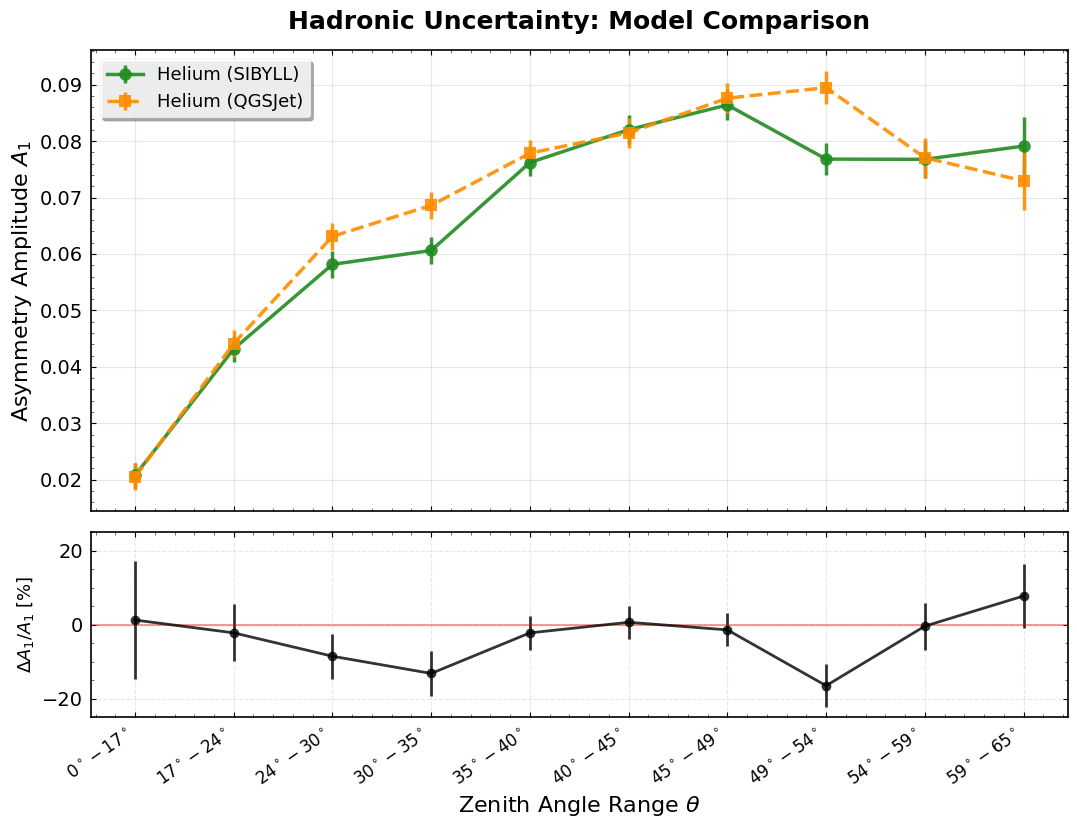

In [56]:
# =========================================================================
# CELDA: ROBUSTEZ HADRÓNICA (HELIO SIBYLL vs QGSJET)
# =========================================================================
import numpy as np
import matplotlib.pyplot as plt

# Diccionarios de configuración visual (Asegurate de tener MARKERS definido, ej: MARKERS = {'SIBYLL': 'o', 'QGSJet': 's'})
LINES = {'SIBYLL': '-', 'QGSJet': '--', 'EPOS': ':'}
COLORS_MOD = {'SIBYLL': 'forestgreen', 'QGSJet': 'darkorange'}

# Filtrar Helio a energía fija (17.5-18.0)
he_data = df_res[(df_res['Primary'] == 'Helio') & 
                 (df_res['Energy'] == '17.5-18.0') & 
                 (df_res['Model'].isin(['SIBYLL', 'QGSJet']))]

# Figura de dos paneles (2 filas, 1 columna)
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(11, 8.5), sharex=True, 
                               gridspec_kw={'height_ratios': [2.5, 1]})
fig.subplots_adjust(hspace=0.08) 

# PANEL SUPERIOR: Evolución de A1
for mod in ['SIBYLL', 'QGSJet']:
    g = he_data[he_data['Model'] == mod].sort_values('ThetaBin')
    # Asumo que MARKERS es un dict global en tu notebook. Si no, poné 'o' directo acá.
    marker = MARKERS.get(mod, 'o') 
    ax1.errorbar(g['ThetaBin'], g['A1'], yerr=g['Err'], 
                 fmt=marker+LINES[mod], color=COLORS_MOD[mod], 
                 label=f"Helium ({mod})", alpha=0.9, capsize=4, markersize=9, lw=2.5)

ax1.set_ylabel(r'Asymmetry Amplitude $A_1$', fontsize=16)
ax1.set_title('Hadronic Uncertainty: Model Comparison', fontsize=18, fontweight='bold', pad=15)
ax1.legend(loc='upper left', fontsize=13)
ax1.grid(True, alpha=0.3)

# PANEL INFERIOR: Diferencia Relativa (%) CON PROPAGACIÓN DE ERRORES
g_sib = he_data[he_data['Model'] == 'SIBYLL'].sort_values('ThetaBin')
g_qgs = he_data[he_data['Model'] == 'QGSJet'].sort_values('ThetaBin')

# Valores y errores
S = g_sib['A1'].values
Q = g_qgs['A1'].values
err_S = g_sib['Err'].values
err_Q = g_qgs['Err'].values

# Calculamos delta / SIBYLL en %
rel_diff = 100 * (S - Q) / S

# Propagación de error (multiplicado por 100 para estar en %)
err_rel_diff = 100 * (1.0 / np.abs(S)) * np.sqrt(err_Q**2 + (Q / S)**2 * err_S**2)

# Ahora graficamos con barras de error
ax2.errorbar(g_sib['ThetaBin'], rel_diff, yerr=err_rel_diff, 
             fmt='ko-', markersize=7, alpha=0.8, lw=2, capsize=4)

ax2.axhline(0, color='red', linestyle='-', lw=1.5, alpha=0.4) # Referencia 0%

ax2.set_ylabel(r'$\Delta A_1 / A_1$ [%]', fontsize=13)
ax2.set_xlabel(r'Zenith Angle Range $\theta$', fontsize=16)
ax2.set_ylim(-25, 25) # Margen de sistemático típico
ax2.grid(True, linestyle='--', alpha=0.3)

# Aplicar etiquetas de bines angulares al eje X final
plt.xticks(range(len(theta_labels)), theta_labels, rotation=35, ha='right', fontsize=12)

plt.tight_layout()
plt.savefig('Hadronic_Uncertainty_Helium.jpg', dpi=300)
plt.show()

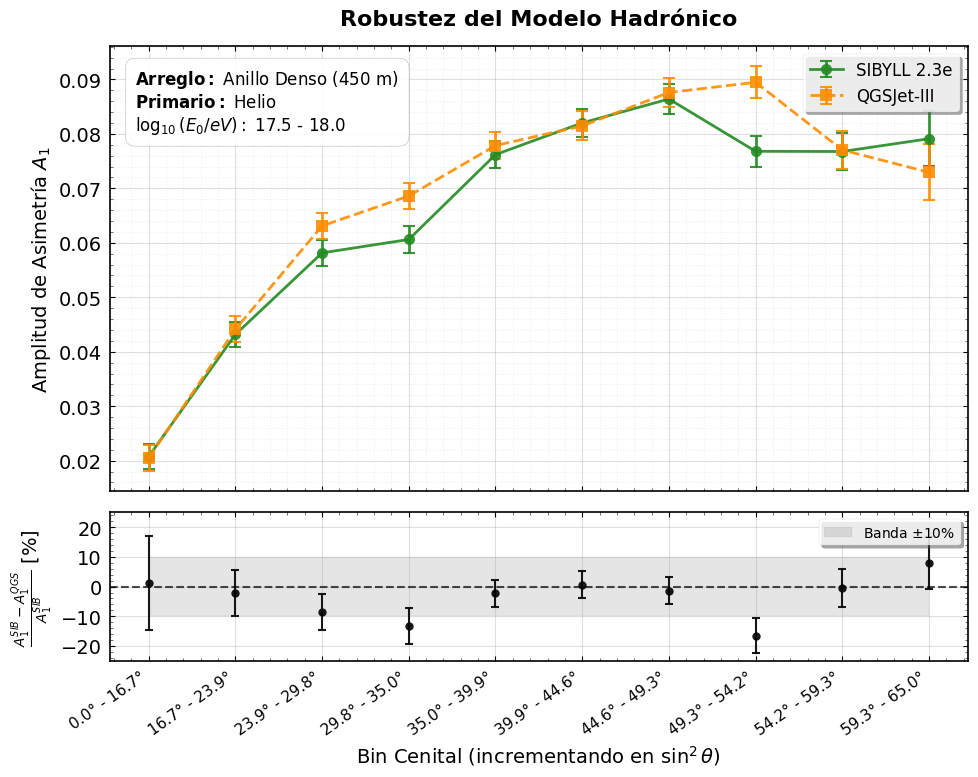

In [30]:
# =========================================================================
# CELDA: ROBUSTEZ HADRÓNICA (HELIO SIBYLL vs QGSJET) - VERSIÓN PUBLICACIÓN
# =========================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Diccionarios de configuración visual
MARKERS = {'SIBYLL': 'o', 'QGSJet': 's'}
LINES = {'SIBYLL': '-', 'QGSJet': '--'}
COLORS_MOD = {'SIBYLL': 'forestgreen', 'QGSJet': 'darkorange'}

# Filtramos los datos de Helio
he_data = df_res[(df_res['Primary'] == 'Helio') & 
                 (df_res['Energy'] == '17.5-18.0') & 
                 (df_res['Model'].isin(['SIBYLL', 'QGSJet']))]

# Figura de dos paneles unidos
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0.05) # Juntamos los paneles

# ==========================================================
# PANEL SUPERIOR: Evolución de A1
# ==========================================================
for mod in ['SIBYLL', 'QGSJet']:
    g = he_data[he_data['Model'] == mod].sort_values('ThetaBin')
    marker = MARKERS.get(mod, 'o') 
    
    ax1.errorbar(g['ThetaBin'], g['A1'], yerr=g['Err'], 
                 fmt=marker+LINES[mod], color=COLORS_MOD[mod], 
                 label=f"{mod}-III" if mod=='QGSJet' else f"{mod} 2.3e", 
                 alpha=0.9, capsize=4, capthick=1.5, markersize=8, lw=2)

ax1.set_ylabel(r'Amplitud de Asimetría $A_1$', fontsize=14)
ax1.set_title('Robustez del Modelo Hadrónico', fontsize=16, fontweight='bold', pad=15)

# Caja de información física (para no tener texto suelto volando)
info_text = (r"$\mathbf{Arreglo:}$ Anillo Denso (450 m)" + "\n" +
             r"$\mathbf{Primario:}$ Helio" + "\n" +
             r"$\log_{10}(E_0/eV):$ 17.5 - 18.0")
props = dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='gray')
ax1.text(0.03, 0.95, info_text, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

ax1.legend(loc='upper right', fontsize=12)
ax1.grid(True, which='major', linestyle='-', alpha=0.4)
ax1.grid(True, which='minor', linestyle=':', alpha=0.2)
ax1.minorticks_on()

# ==========================================================
# PANEL INFERIOR: Diferencia Relativa (%)
# ==========================================================
g_sib = he_data[he_data['Model'] == 'SIBYLL'].sort_values('ThetaBin')
g_qgs = he_data[he_data['Model'] == 'QGSJet'].sort_values('ThetaBin')

S = g_sib['A1'].values
Q = g_qgs['A1'].values
err_S = g_sib['Err'].values
err_Q = g_qgs['Err'].values

# Diferencia relativa porcentual y propagación de errores
rel_diff = 100 * (S - Q) / S
err_rel_diff = 100 * np.abs(1.0 / S) * np.sqrt(err_Q**2 + (Q / S)**2 * err_S**2)

# Referencia del cero y banda de tolerancia (+/- 10%)
ax2.axhline(0, color='black', linestyle='--', lw=1.5, alpha=0.7)
ax2.fill_between(g_sib['ThetaBin'], -10, 10, color='gray', alpha=0.2, label=r'Banda $\pm 10\%$')

# Puntos de diferencia con barras de error
ax2.errorbar(g_sib['ThetaBin'], rel_diff, yerr=err_rel_diff, 
             fmt='ko', markersize=6, alpha=0.9, lw=1.5, capsize=3, capthick=1.5)

ax2.set_ylabel(r'$\frac{A_1^{SIB} - A_1^{QGS}}{A_1^{SIB}}$ [%]', fontsize=14)
ax2.set_xlabel(r'Bin Cenital (incrementando en $\sin^2\theta$)', fontsize=14)

# Forzamos los límites del eje Y para que no salte locamente
ax2.set_ylim(-25, 25)
ax2.yaxis.set_major_locator(ticker.MultipleLocator(10))

ax2.grid(True, which='major', linestyle='-', alpha=0.4)
ax2.legend(loc='upper right', fontsize=10)

# ==========================================================
# RETOQUES FINALES Y EJE X
# ==========================================================
# Asumo que theta_labels es una lista con los strings de tus bines
ax2.set_xticks(g_sib['ThetaBin'])
ax2.set_xticklabels(theta_labels, rotation=35, ha='right', fontsize=11)

plt.tight_layout()
plt.savefig('Hadronic_Uncertainty_Helium.pdf', dpi=300, bbox_inches='tight')
plt.show()